<a href="https://colab.research.google.com/github/Reeva-17/Customer-Churn-Prediction/blob/main/notebooks/04_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Import libraries

import os
import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [4]:
# Clone repository

if not os.path.exists("/content/Customer-Churn-Prediction"):
    !git clone https://github.com/Reeva-17/Customer-Churn-Prediction.git

%cd /content/Customer-Churn-Prediction/notebooks

Cloning into 'Customer-Churn-Prediction'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 132 (delta 66), reused 9 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 2.62 MiB | 6.49 MiB/s, done.
Resolving deltas: 100% (66/66), done.
/content/Customer-Churn-Prediction/notebooks


In [5]:
# Verify folders
!pwd
!ls ..
!ls ../data/processed

/content/Customer-Churn-Prediction/notebooks
app  data  images  models  notebooks  README.md  reports  svm_model.pkl
customer_churn_processed.csv  X_test.csv  X_train.csv  y_test.csv  y_train.csv


In [6]:
# Load datasets
base_path = "../data/processed"

X_train = pd.read_csv(f"{base_path}/X_train.csv")
X_test = pd.read_csv(f"{base_path}/X_test.csv")

y_train = pd.read_csv(f"{base_path}/y_train.csv")
y_test = pd.read_csv(f"{base_path}/y_test.csv")

In [7]:
# Convert targets

y_train = y_train.squeeze()
y_test = y_test.squeeze()

print(type(y_train))
print(type(y_test))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


Churn
0    4130
1    1495
Name: count, dtype: int64


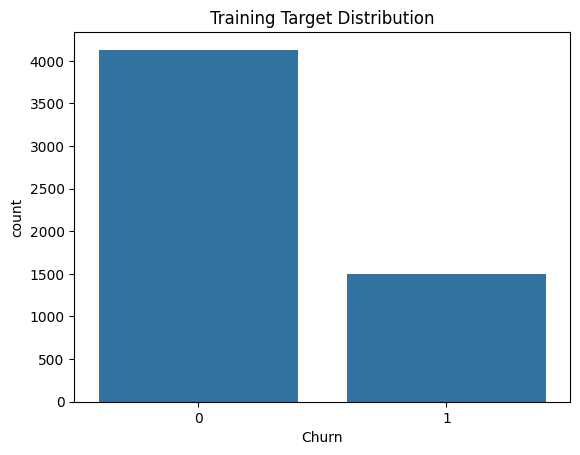

In [8]:
# Target distribution
print(y_train.value_counts())
sns.countplot(x=y_train)
plt.title("Training Target Distribution")
plt.show()

In [9]:
from sklearn.model_selection import GridSearchCV

In [10]:
# Define model

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [11]:
# Define parameters

param_grid = {
    "C":[0.01,0.1,1,10],
    "penalty":["l2"],
    "solver":["lbfgs"]
}

In [12]:
# Tune model

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='f1')

In [13]:
# Best parameters

print("Best Parameters :",grid_search.best_params_)
print("Best CV Accuracy :",grid_search.best_score_)

Best Parameters : {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Accuracy : 0.5961706129226705


In [14]:
# Best model
best_model = grid_search.best_estimator_

In [15]:
# Training accuracy

train_accuracy = best_model.score(X_train,y_train)

print(f"Training Accuracy : {train_accuracy:.4f}")

Training Accuracy : 0.8053


In [16]:
# Make predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [17]:
# Evaluate model

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_prob)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

Accuracy  : 0.8003
Precision : 0.6388
Recall    : 0.5722
F1 Score  : 0.6037
ROC AUC   : 0.8354


In [18]:
# Classification report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.74      1407
weighted avg       0.79      0.80      0.80      1407



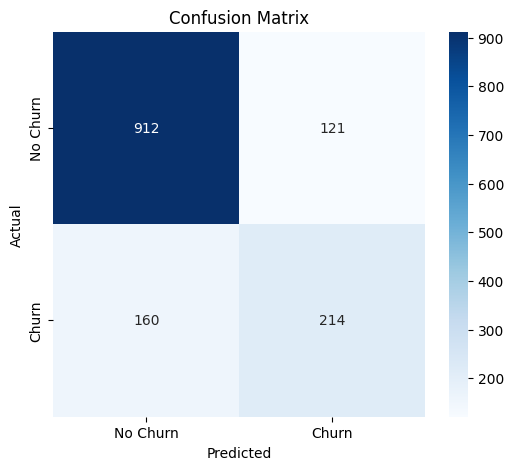

In [19]:
# Confusion matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

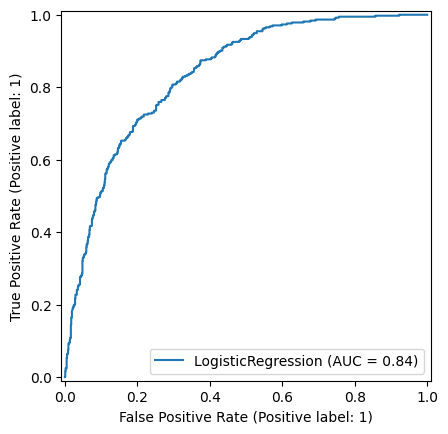

In [20]:
# Plot ROC curve

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.show()


In [21]:
# Check overfitting
train_pred = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
train_precision = precision_score(y_train, train_pred)
train_recall = recall_score(y_train, train_pred)
train_f1 = f1_score(y_train, train_pred)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

comparison = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1 Score"],
    "Train":[train_accuracy,train_precision,train_recall,train_f1],
    "Test":[test_accuracy,test_precision,test_recall,test_f1]
})

comparison["Difference"] = abs(comparison["Train"]-comparison["Test"])

comparison

,Metric,Train,Test,Difference
0,Accuracy,0.805333,0.800284,0.005049
1,Precision,0.659490,0.638806,0.020684
2,Recall,0.553177,0.572193,0.019015
3,F1 Score,0.601673,0.603667,0.001994


In [22]:
# Save model
import joblib
joblib.dump(
    best_model,
    "../models/logistic_regression.pkl"
)
print("Model saved successfully!")

Model saved successfully!


In [23]:
# Verify model
!ls ../models

decision_tree.pkl	 random_forest.pkl  xgboost_model.pkl
logistic_regression.pkl  svm_model.pkl


In [24]:
# Create results dataframe
import pandas as pd
results_df = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC-AUC": [roc_auc]
})



In [25]:
# Save to reports folder
results_df.to_csv("../reports/logistic_regression_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!
